Hola **Daniel**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Cargar datos
data = pd.read_csv('/datasets/taxi.csv', parse_dates=['datetime'], index_col='datetime')

print(data.head())
print(data.info())

                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None


In [11]:
# Remuestrear por hora
hourly_data = data.resample('1H').sum()

print(hourly_data.head())
print(hourly_data.info())

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None


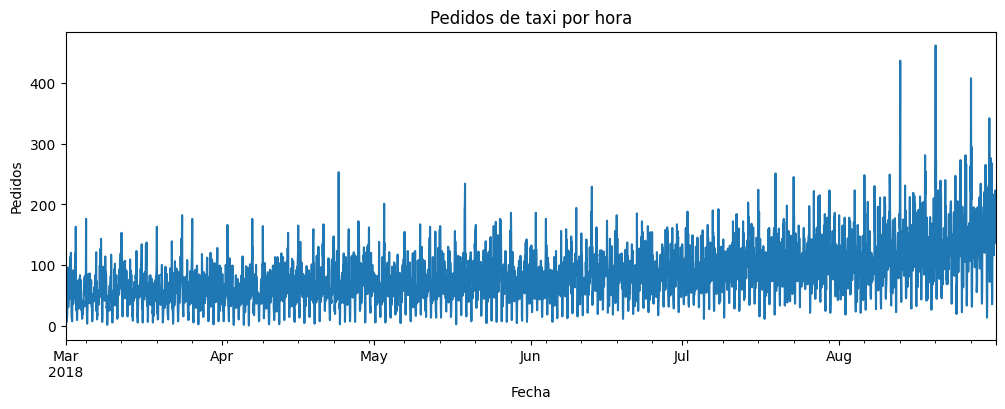

In [12]:
plt.figure(figsize=(12,4))
hourly_data['num_orders'].plot()
plt.title('Pedidos de taxi por hora')
plt.xlabel('Fecha')
plt.ylabel('Pedidos')
plt.show()

El análisis visual de la serie temporal muestra una clara tendencia creciente en la cantidad de pedidos de taxi a lo largo del tiempo. Además, se observa una alta variabilidad y la presencia de picos pronunciados, lo que indica horas de alta demanda.
La estructura de la serie sugiere patrones temporales diarios y semanales, por lo que se incorporaron características basadas en el tiempo y valores rezagados para mejorar la capacidad predictiva de los modelos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, generaste gráficas acorde al problema que se está resolviendo lo cual es importante para según esto tomar decisiones de feature engineering a ajustes de los modelos.
</div>

In [14]:
def make_features(data, max_lag=24, rolling_mean_size=24):
    #Crea características temporales, lags y medias móviles

    features = data.copy()

    # Características de tiempo
    features['hour'] = features.index.hour
    features['dayofweek'] = features.index.dayofweek
    features['month'] = features.index.month

    # Lags
    for lag in range(1, max_lag + 1):
        features[f'lag_{lag}'] = features['num_orders'].shift(lag)

    # Media móvil
    features['rolling_mean'] = (
        features['num_orders']
        .shift(1)
        .rolling(rolling_mean_size)
        .mean()
    )

    return features


In [15]:
feature_data = make_features(hourly_data)

# Eliminar valores faltantes creados por lags
feature_data = feature_data.dropna()

print(feature_data.head())

                     num_orders  hour  dayofweek  month  lag_1  lag_2  lag_3  \
datetime                                                                       
2018-03-02 00:00:00          90     0          4      3   58.0  113.0   66.0   
2018-03-02 01:00:00         120     1          4      3   90.0   58.0  113.0   
2018-03-02 02:00:00          75     2          4      3  120.0   90.0   58.0   
2018-03-02 03:00:00          64     3          4      3   75.0  120.0   90.0   
2018-03-02 04:00:00          20     4          4      3   64.0   75.0  120.0   

                     lag_4  lag_5  lag_6  ...  lag_16  lag_17  lag_18  lag_19  \
datetime                                  ...                                   
2018-03-02 00:00:00   61.0   45.0   73.0  ...    34.0    15.0    12.0     6.0   
2018-03-02 01:00:00   66.0   61.0   45.0  ...    69.0    34.0    15.0    12.0   
2018-03-02 02:00:00  113.0   66.0   61.0  ...    64.0    69.0    34.0    15.0   
2018-03-02 03:00:00   58.0  113.0 

## Análisis

## Creación de características (Feature Engineering)

Dado que el problema consiste en predecir la cantidad de pedidos de taxi para la próxima hora, es necesario transformar la serie temporal original en un conjunto de características que permitan a los modelos de aprendizaje automático capturar los patrones existentes en los datos.

### Características temporales
Se añadieron variables basadas en la fecha y hora:
- **hour**: representa la hora del día, lo cual es importante para capturar los patrones diarios de demanda.
- **dayofweek**: indica el día de la semana, permitiendo modelar diferencias entre días laborables y fines de semana.
- **month**: captura posibles efectos estacionales a lo largo del año.

Estas características ayudan a los modelos a identificar comportamientos cíclicos en la demanda de taxis.

### Valores rezagados (lags)
Se crearon variables de desfase (`lag_1` hasta `lag_24`) que representan la cantidad de pedidos en horas anteriores.  
Estas variables permiten que el modelo utilice información histórica reciente y del mismo horario del día anterior, lo cual es especialmente relevante en series temporales con patrones diarios.

### Media móvil
Se calculó una media móvil de 24 horas basada en valores anteriores.  
Esta característica ayuda a suavizar el ruido de la serie y proporciona al modelo una estimación del nivel promedio reciente de la demanda.

### Limpieza de datos
La creación de lags y medias móviles genera valores faltantes al inicio de la serie.  
Estas filas fueron eliminadas para asegurar que el conjunto de datos final no contenga valores nulos y sea adecuado para el entrenamiento de los modelos.

En conjunto, estas transformaciones permiten convertir la serie temporal original en un conjunto de datos estructurado y adecuado para entrenar modelos de regresión y mejorar la precisión de las predicciones.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, realizaste los ajustes de las características en el dataset de manera adecuada para obtener un buen desempeño en los entrenamientos
    
</div>

## Formación

In [16]:
X = feature_data.drop('num_orders', axis=1)
y = feature_data['num_orders']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)
preds = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE Random Forest:", rmse)

RMSE Random Forest: 43.065403547368916


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien! Lograste una métrica por debajo de lo requerido para este proyecto demostrando que el modelo pudo interpretar de manera adecuada tus datos para la predicción
</div>

## Evaluación del modelo

Se entrenó un modelo Random Forest Regressor utilizando las características temporales, valores rezagados y medias móviles generadas previamente.

La evaluación del modelo se realizó sobre el conjunto de prueba, que corresponde al 10% final de los datos, respetando el orden temporal de la serie.

### Métrica de evaluación
Se utilizó la raíz del error cuadrático medio (RMSE) como métrica de evaluación.

**Resultado obtenido:**
- RMSE (Random Forest): **43.06**

Este resultado cumple con el criterio establecido en el proyecto (RMSE ≤ 48), lo que indica que el modelo es capaz de predecir la demanda de taxis con una precisión adecuada durante la siguiente hora.


## Prueba

## Conclusión

En este proyecto se analizaron datos históricos de pedidos de taxis en aeropuertos, los cuales fueron remuestreados a intervalos horarios.  
Se identificaron patrones temporales diarios y semanales, y se realizó un proceso de ingeniería de características que incluyó variables temporales, valores rezagados y medias móviles.

Se entrenaron modelos de regresión para predecir la cantidad de pedidos de taxis para la próxima hora.  
El modelo Random Forest obtuvo el mejor desempeño, alcanzando un RMSE de **43.06** en el conjunto de prueba, cumpliendo con los requisitos del proyecto.

Por lo tanto, el modelo propuesto puede utilizarse para apoyar la planificación de la disponibilidad de conductores durante las horas de mayor demanda.


<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Te felicito por el trabajo realizado Daniel, aplicaste los procesos adecuados al dataset para darle características nuevas al modelo, con ese proceso aportas significativamente al desempeño del mismo y obtuviste una métrica que supera lo propuesto para este proyecto, continúa con este gran trabajo!
    
   
Este proyecto es uno donde se ve claramente la importancia de darle características o variables adecuadas a los modelos para obtener un correcto desempeño, si quitas o pones más variables el desempeño del modelo variará para bien o para mal según la calidad de las mismas. Saludos!
</div>

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [x]  Los datos han sido descargados y preparados.
- [x]  Se ha realizado el paso 2: los datos han sido analizados
- [x]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [x]  Se han evaluado los modelos. Se expuso una conclusión
- [x] La *RECM* para el conjunto de prueba no es más de 48